# Temas Tratados en el Trabajo Práctico 5

* Comportamiento y operaciones bajo incertidumbre.

* Teorema de Bayes.

* Representación de la información incierta en Redes Bayesianas.

* Inferencia por enumeración.

* Redes de Markov y matrices de transición.

* Tiempo esperado y probabilidad de absorción.


## Ejercicios Teóricos

1. ¿Cuáles son los tres axiomas de Kolmogorov?

### Resolución

Los **axiomas de Kolmogórov** establecen las condiciones fundamentales que debe cumplir una función de probabilidad.

Sea $\Omega$ el espacio muestral de un experimento aleatorio y sea $A$ un evento, es decir, un subconjunto de $\Omega$. Una función de probabilidad $P$ debe cumplir los siguientes tres axiomas:

#### 1. No negatividad

La probabilidad de cualquier evento debe ser mayor o igual que cero:

$$
P(A)\geq 0
$$

Una probabilidad negativa no tendría interpretación válida como proporción o grado de creencia.

#### 2. Normalización

La probabilidad del espacio muestral completo es igual a uno:

$$
P(\Omega)=1
$$

El espacio muestral contiene todos los resultados posibles, por lo que existe certeza de que ocurrirá alguno de ellos.

#### 3. Aditividad numerable

Si $A_1,A_2,\ldots$ son eventos mutuamente excluyentes, es decir:

$$
A_i\cap A_j=\varnothing
\qquad \text{para } i\neq j
$$

entonces la probabilidad de su unión es igual a la suma de sus probabilidades:

$$
P\left(\bigcup_{i=1}^{\infty}A_i\right)
=
\sum_{i=1}^{\infty}P(A_i)
$$

Por ejemplo, al lanzar un dado equilibrado, los eventos “obtener 1” y “obtener 2” son mutuamente excluyentes. Por lo tanto:

$$
P(\{1,2\})=P(\{1\})+P(\{2\})
=\frac{1}{6}+\frac{1}{6}
=\frac{1}{3}
$$

A partir de estos axiomas se obtienen propiedades importantes como:

$$
P(\varnothing)=0
$$

$$
P(A^c)=1-P(A)
$$

$$
0\leq P(A)\leq1
$$

Por lo tanto, los axiomas de Kolmogórov garantizan que las probabilidades asignadas a los eventos sean matemáticamente coherentes.


2. Una fábrica de clavos dispone de 2 máquinas que elaboran el 30% y 70% de los clavos que producen respectivamente. El porcentaje de clavos defectuosos de cada máquina es del 2% y 3%, respectivamente. Si se selecciona al azar un clavo de la producción y este fue defectuoso, ¿cuál es la probabilidad de que haya sido fabricado por la máquina?

### Resolución

Definimos los siguientes eventos:

- $M_1$: el clavo fue fabricado por la máquina 1.
- $M_2$: el clavo fue fabricado por la máquina 2.
- $D$: el clavo seleccionado es defectuoso.

Las probabilidades de producción de cada máquina son:

$$
P(M_1)=0.30
$$

$$
P(M_2)=0.70
$$

Las probabilidades condicionales de producir un clavo defectuoso son:

$$
P(D\mid M_1)=0.02
$$

$$
P(D\mid M_2)=0.03
$$

Primero calculamos la probabilidad total de seleccionar un clavo defectuoso mediante la regla de probabilidad total:

$$
P(D)
=
P(D\mid M_1)P(M_1)
+
P(D\mid M_2)P(M_2)
$$

Reemplazando:

$$
P(D)
=
0.02(0.30)+0.03(0.70)
$$

$$
P(D)=0.006+0.021=0.027
$$

Por lo tanto, la probabilidad general de seleccionar un clavo defectuoso es:

$$
\boxed{P(D)=0.027=2.7\%}
$$

Aplicando el teorema de Bayes para la máquina 1:

$$
P(M_1\mid D)
=
\frac{P(D\mid M_1)P(M_1)}
{P(D)}
$$

$$
P(M_1\mid D)
=
\frac{0.02(0.30)}{0.027}
=
\frac{0.006}{0.027}
\approx0.2222
$$

Por lo tanto:

$$
\boxed{P(M_1\mid D)\approx22.22\%}
$$

Para la máquina 2:

$$
P(M_2\mid D)
=
\frac{P(D\mid M_2)P(M_2)}
{P(D)}
$$

$$
P(M_2\mid D)
=
\frac{0.03(0.70)}{0.027}
=
\frac{0.021}{0.027}
\approx0.7778
$$

Por lo tanto:

$$
\boxed{P(M_2\mid D)\approx77.78\%}
$$

Se verifica que:

$$
P(M_1\mid D)+P(M_2\mid D)=1
$$

En conclusión, si el clavo seleccionado es defectuoso, existe aproximadamente un **22.22% de probabilidad de que haya sido fabricado por la máquina 1** y un **77.78% de probabilidad de que haya sido fabricado por la máquina 2**.

3. La probabilidad de que un motor que sale de una fábrica con una *avería eléctrica* es de $10^{-3}$, y la probabilidad de que salga con una *avería mecánica* es de $10^{-5}$. Si existe un tipo de avería no se producen averías del otro tipo.
<br><br>Si el motor presenta *temperatura elevada* se enciende un *piloto luminoso* el 95% de las veces, cuando la *temperatura es reducida* el *piloto luminoso* se enciende el 99% de las veces, y a veces cuando la *temperatura se encuentra en un rango normal* el *piloto luminoso* se enciende erróneamente en un caso por millón.
<br><br>Cuando *no hay averías*, la *temperatura se eleva* en el 17% de los casos y es *reducida* el 5% de las veces. Si hay una *avería eléctrica*, la *temperatura se eleva* en el 90% de los casos y es *reducida* en el 1% de los casos. Finalmente cuando la *avería es mecánica*, la *temperatura está elevada* el 10% de los casos y *reducida* el 40% de las veces.
<br><br>Construya una Red Bayesiana y utilice inferencia por enumeración para calcular:

        3.1 La probabilidad de que el motor tenga una avería mecánica si se enciende el piloto.

        3.2 La probabilidad de que el motor tenga una avería mecánica si se enciende el piloto y la temperatura es elevada.

### Resolución

#### Definición de los eventos

Para construir la red bayesiana se definen los siguientes eventos:

- $AM$: el motor presenta una avería mecánica.
- $AE$: el motor presenta una avería eléctrica.
- $TE$: el motor presenta temperatura elevada.
- $TR$: el motor presenta temperatura reducida.
- $TN$: el motor presenta temperatura normal.
- $P$: el piloto luminoso se enciende.

Las probabilidades iniciales de las averías son:

$$
P(AE)=10^{-3}=0.001
$$

$$
P(AM)=10^{-5}=0.00001
$$

La consigna indica que las averías eléctrica y mecánica son mutuamente excluyentes. Por lo tanto, no pueden ocurrir simultáneamente:

$$
P(AE\cap AM)=0
$$

Esto implica que:

$$
P(AE\mid AM)=0
$$

y:

$$
P(\neg AE\mid AM)=1
$$

Esta es la rama que se trunca en el árbol: si ya sabemos que existe una avería mecánica, la rama correspondiente a una avería eléctrica tiene probabilidad cero y no debe seguir desarrollándose.

La probabilidad de que el motor no tenga ninguna avería es:

$$
P(\neg AM,\neg AE)
=
1-P(AM)-P(AE)
$$

$$
P(\neg AM,\neg AE)
=
1-0.00001-0.001
$$

$$
P(\neg AM,\neg AE)=0.99899
$$

Si primero se divide el árbol según $AM$, entonces:

$$
P(\neg AM)=1-P(AM)=0.99999
$$

Dentro de la rama $\neg AM$, la probabilidad condicional de una avería eléctrica es:

$$
P(AE\mid\neg AM)
=
\frac{P(AE)}{P(\neg AM)}
$$

$$
P(AE\mid\neg AM)
=
\frac{0.001}{0.99999}
\approx0.00100001
$$

y la probabilidad de que tampoco exista una avería eléctrica es:

$$
P(\neg AE\mid\neg AM)
=
\frac{0.99899}{0.99999}
\approx0.99899999
$$

Por lo tanto, las tres ramas posibles asociadas al estado del motor son:

1. $AM\land\neg AE$: avería mecánica.
2. $\neg AM\land AE$: avería eléctrica.
3. $\neg AM\land\neg AE$: motor sin averías.

La cuarta combinación, $AM\land AE$, es imposible y se trunca.

#### Estados de temperatura

La temperatura puede encontrarse en uno de tres estados mutuamente excluyentes:

$$
T\in\{TE,TR,TN\}
$$

Las probabilidades condicionales son:

| Estado del motor | $P(TE)$ | $P(TR)$ | $P(TN)$ |
|---|---:|---:|---:|
| Sin avería | $0.17$ | $0.05$ | $0.78$ |
| Avería eléctrica | $0.90$ | $0.01$ | $0.09$ |
| Avería mecánica | $0.10$ | $0.40$ | $0.50$ |

Las probabilidades de temperatura normal se obtienen por complemento. Por ejemplo:

$$
P(TN\mid AM)
=
1-P(TE\mid AM)-P(TR\mid AM)
$$

$$
P(TN\mid AM)=1-0.10-0.40=0.50
$$

#### Orden de enumeración del árbol

Siguiendo el orden utilizado en clase, el árbol se desarrolla como:

$$
AM\longrightarrow AE\longrightarrow TE\longrightarrow TR\longrightarrow P
$$

Después de determinar las averías, primero se comprueba si la temperatura es elevada. Si no es elevada, se comprueba si es reducida. Si no es elevada ni reducida, entonces es normal.

Para que las ramas de temperatura sumen uno, cuando se pregunta por $TR$ después de haber observado $\neg TE$ debe utilizarse:

$$
P(TR\mid\neg TE,F)
=
\frac{P(TR\mid F)}
{1-P(TE\mid F)}
$$

donde $F$ representa el estado de avería.

Por ejemplo, para una avería mecánica:

$$
P(TR\mid\neg TE,AM)
=
\frac{0.40}{1-0.10}
=
\frac{0.40}{0.90}
=
\frac{4}{9}
$$

De esta manera, la probabilidad conjunta de la rama $\neg TE\land TR$ sigue siendo:

$$
P(\neg TE\mid AM)
P(TR\mid\neg TE,AM)
=
0.90\left(\frac{4}{9}\right)
=
0.40
$$

Finalmente, las probabilidades de encendido del piloto son:

$$
P(P\mid TE)=0.95
$$

$$
P(P\mid TR)=0.99
$$

$$
P(P\mid TN)=10^{-6}
$$

La distribución conjunta de la red puede factorizarse como:

$$
P(F,T,P)=P(F)P(T\mid F)P(P\mid T)
$$

donde $F$ representa el estado de avería y $T$ el estado de temperatura.

In [2]:
%pip install networkx

     ---------------------------------------- 2.1/2.1 MB 5.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


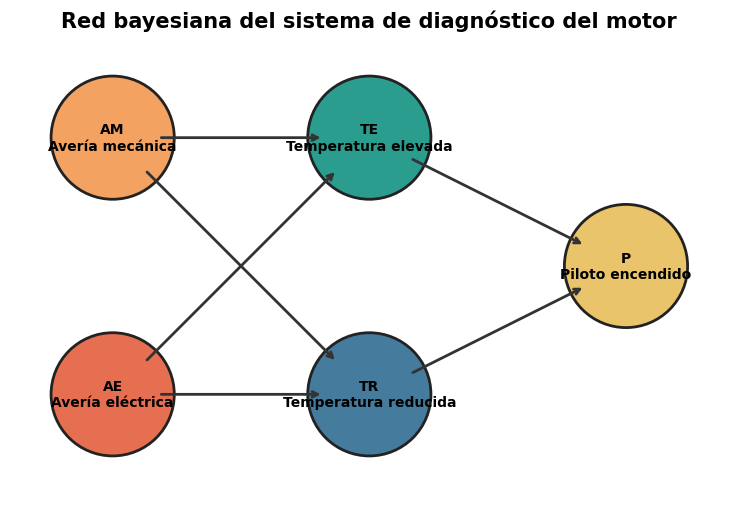

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(11, 6))

# Posiciones similares a las del pizarrón.
posiciones = {
    "AM": (0, 2),
    "AE": (0, 0),
    "TE": (2, 2),
    "TR": (2, 0),
    "P":  (4, 1)
}

etiquetas = {
    "AM": "AM\nAvería mecánica",
    "AE": "AE\nAvería eléctrica",
    "TE": "TE\nTemperatura elevada",
    "TR": "TR\nTemperatura reducida",
    "P":  "P\nPiloto encendido"
}

colores = {
    "AM": "#f4a261",
    "AE": "#e76f51",
    "TE": "#2a9d8f",
    "TR": "#457b9d",
    "P":  "#e9c46a"
}

# Relaciones de dependencia.
conexiones = [
    ("AM", "TE"),
    ("AM", "TR"),
    ("AE", "TE"),
    ("AE", "TR"),
    ("TE", "P"),
    ("TR", "P")
]

# Dibujamos las flechas.
for origen, destino in conexiones:
    ax.annotate(
        "",
        xy=posiciones[destino],
        xytext=posiciones[origen],
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 2,
            "color": "#333333",
            "shrinkA": 35,
            "shrinkB": 35
        }
    )

# Dibujamos los nodos.
for nodo, (x, y) in posiciones.items():
    circulo = Circle(
        (x, y),
        radius=0.48,
        facecolor=colores[nodo],
        edgecolor="#222222",
        linewidth=2
    )

    ax.add_patch(circulo)

    ax.text(
        x,
        y,
        etiquetas[nodo],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Red bayesiana del sistema de diagnóstico del motor",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlim(-0.8, 4.8)
ax.set_ylim(-0.8, 2.8)
ax.set_aspect("equal")
ax.axis("off")

plt.show()

4. Cada día se procesa un producto en secuencia en dos máquinas, M1 y M2. Una inspección se realiza después de que una unidad del producto se completa en cualquiera de las máquinas. 
<br><br>Hay un 5% de probabilidades de que una unidad sea desechada antes de inspeccionarla. Después de la inspección, hay un 3% de probabilidades de que la unidad sea desechada y un 7% de probabilidades de ser devuelta a la misma máquina para trabajarla
de nuevo. Si una unidad pasa la inspección en ambas máquinas es
buena.

        4.1 Dibuje la cadena de Markov que representa este problema y describa para cada estado si es transitorio, recurrente, o absorbente.

        4.2 Arme la matriz de transición

        4.3 Calcule la probabilidad de que una pieza que inicia el proceso en la máquina M1 sea desechada.

        4.4 Calcule la probabilidad de que una pieza de la máquina M2 sea terminada.

        4.5 Si los tiempos de procesamiento en las máquinas M1 y M2 son respectivamente de 20 y 30 minutos y los tiempos de inspección son respectivamente de 5 y 7 minutos, ¿cuánto tiempo tarda en ser procesada una pieza que inicia en la máquina M1?

## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

5. Diseñar un controlador difuso para jugar al Pong. El juego consiste en una pelota que rebota dentro de una cancha rectangular y palas controladas por el sistema difuso o el jugador. El entorno debe cumplir las siguientes reglas:

* La cancha posee dimensiones fijas.
* La pelota rebota en los bordes superior e inferior. Los bordes laterales funcionan como un arco y cuando la pelota atraviesa un borde suma un punto al lado opuesto, sin importar quién toca la pelota por última vez.
* La velocidad de la pelota debe ir incrementando con cada rebot en una pala o pared. Marcar un gol restablece los valores de velocidad a su configuración original.
* Cada pala únicamente puede desplazarse verticalmente y con velocidad fija durante toda la ejecución.
* Cada pala tiene una altura fija.
* Es necesario definir un puntaje mínimo que de el juego por finalizado.

La variable de salida sobre la que actúa el controlador es la **velocidad de la pala**. Las variables de entrada quedan a definir por ustedes.

Como mínimo deben hacer un modo de "un jugador" (ustedes vs. el agente), pero pueden incorporar un modo de "dos jugadores" que consista en utilizar dos agentes con variaciones en las reglas del motor de inferencia, mecanismos de fuzzificación o desfuzzificación de la información y/o las funciones de pertenencia de cada grupo.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)
